In [19]:
# Подгрузка библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import datetime

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pandas.plotting import autocorrelation_plot

from sklearn.metrics import mean_squared_error
import math

In [20]:
# Загрузка данных

start = '2015-01-01'
end = '2025-01-01'

series = yf.download("AMZN", start=start, end=end)

print("Количество наблюдений:", len(series))

series.head()

/tmp/ipykernel_14886/4011503550.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  series = yf.download("AMZN", start=start, end=end)
[*********************100%***********************]  1 of 1 completed

Количество наблюдений: 2516


Price,Close,High,Low,Open,Volume
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN
Date,,,,,
2015-01-02,15.4260,15.7375,15.3480,15.6290,55664000
2015-01-05,15.1095,15.4190,15.0425,15.3505,55484000
2015-01-06,14.7645,15.1500,14.6190,15.1120,70380000
2015-01-07,14.9210,15.0640,14.7665,14.8750,52806000
2015-01-08,15.0230,15.1570,14.8055,15.0160,61768000


/tmp/ipykernel_14886/4011503550.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  series = yf.download("AMZN", start=start, end=end)
[*********************100%***********************]  1 of 1 completed


Количество наблюдений: 2516


Price,Close,High,Low,Open,Volume
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN
Date,,,,,
2015-01-02,15.4260,15.7375,15.3480,15.6290,55664000
2015-01-05,15.1095,15.4190,15.0425,15.3505,55484000
2015-01-06,14.7645,15.1500,14.6190,15.1120,70380000
2015-01-07,14.9210,15.0640,14.7665,14.8750,52806000
2015-01-08,15.0230,15.1570,14.8055,15.0160,61768000


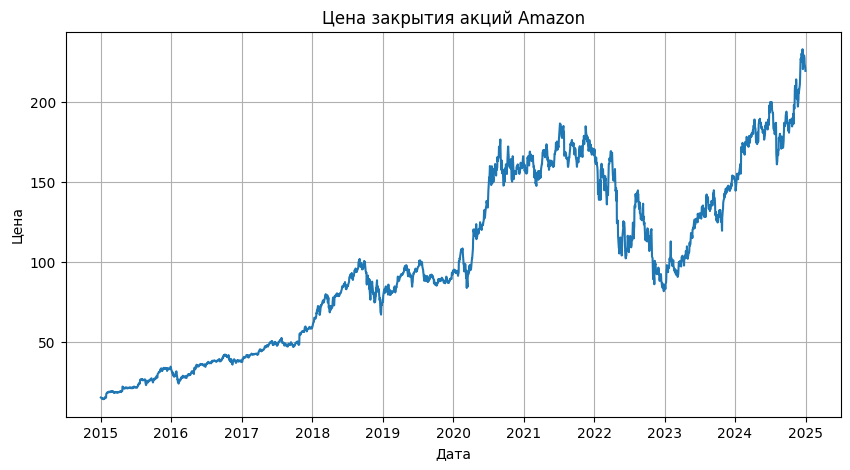

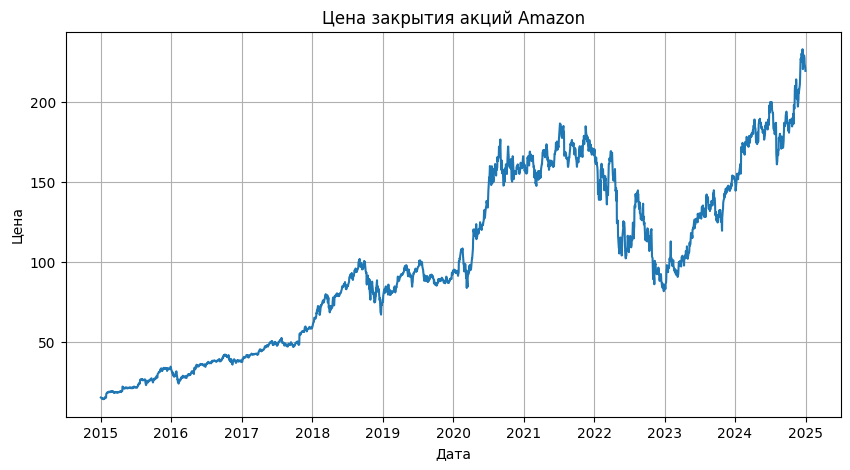

In [21]:
# График исходного ряда

plt.figure(figsize=(10,5))
plt.plot(series['Close'])
plt.title("Цена закрытия акций Amazon")
plt.xlabel("Дата")
plt.ylabel("Цена")
plt.grid()
plt.show()

<Figure size 1000x500 with 0 Axes>

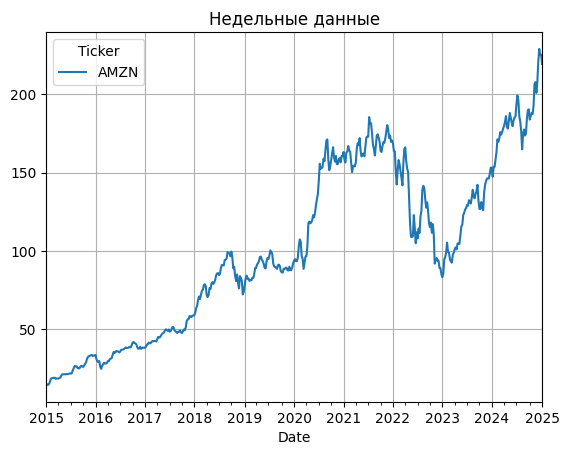

/tmp/ipykernel_14886/3610223271.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  series['Close'].resample('M').mean().plot()


<Figure size 1000x500 with 0 Axes>

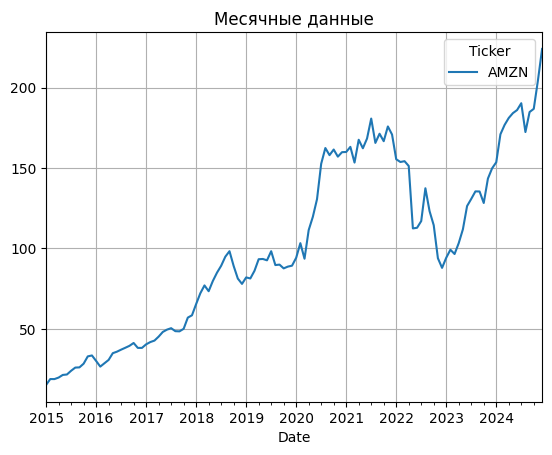

In [22]:
# Изменение периодичности

plt.figure(figsize=(10,5))
series['Close'].resample('W-MON').mean().plot()
plt.title("Недельные данные")
plt.grid()
plt.show()

plt.figure(figsize=(10,5))
series['Close'].resample('M').mean().plot()
plt.title("Месячные данные")
plt.grid()
plt.show()

Данные представляют собой недельные значения цены акций Amazon (тикер: AMZN) за период с 2015 по 2025 год.

Основная динамика:

2015–2016: Цена держится в диапазоне 20–40.

2017–2018: Рост до 60–80.

2019–2020: Колебания в коридоре 85–100.

2021: Скачок до 160–165.

2022: Пик в районе 170, затем снижение до 155.

2023: Падение до 120, затем восстановление до 145.

2024–2025: Активный рост до 175, с максимумом в 205 к концу периода.

График отображает среднемесячные цены закрытия акций Amazon (AMZN) за период с 2015 по 2024 год.

Ключевые точки динамики:

2015–2018: Плавный восходящий тренд с отметки около 50 до 150.

2018–2020: Рост ускоряется, цена поднимается выше 150.

2021: Формируется пик в районе 180–190.

2022: Резкое снижение до уровней 100–120.

2023–2024: Восстановление и выход на новые максимумы выше 200 к концу 2024 года.

/tmp/ipykernel_14886/4195363917.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  plot_acf(series['Close'].resample('M').mean(), ax=axes[0,2], lags=25)
/tmp/ipykernel_14886/4195363917.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  plot_pacf(series['Close'].resample('M').mean(), ax=axes[1,2], lags=25)


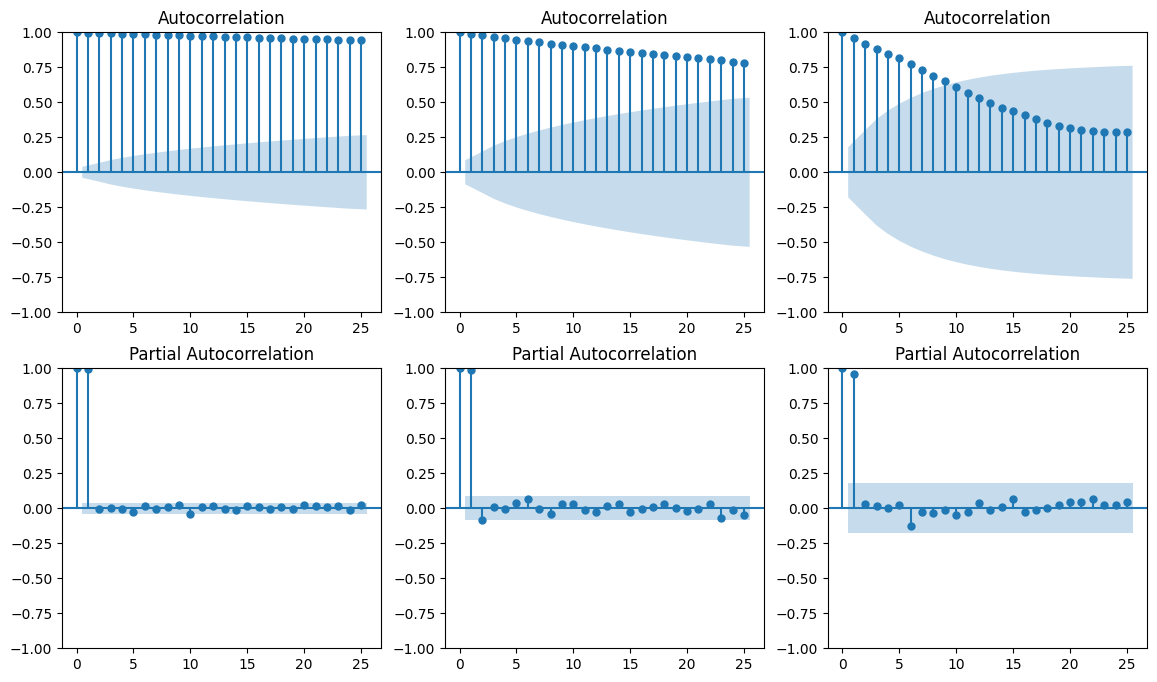

In [23]:
# ACF и PACF

fig, axes = plt.subplots(2, 3, figsize=(14,8))

plot_acf(series['Close'], ax=axes[0,0], lags=25)
plot_pacf(series['Close'], ax=axes[1,0], lags=25)

plot_acf(series['Close'].resample('W').mean(), ax=axes[0,1], lags=25)
plot_pacf(series['Close'].resample('W').mean(), ax=axes[1,1], lags=25)

plot_acf(series['Close'].resample('M').mean(), ax=axes[0,2], lags=25)
plot_pacf(series['Close'].resample('M').mean(), ax=axes[1,2], lags=25)

plt.show()

**Первое распределение:**

Минимум: -0.25

Нижний квартиль: 0.00

Медиана: 1.00

Верхний квартиль: 1.00

Максимум: 1.00

Выбросы: множество положительных значений от 0.005 до 1.00

**Второе распределение:**

Минимум: -0.25

Нижний квартиль: -0.25

Медиана: 1.00

Верхний квартиль: 1.00

Максимум: 1.00

Выбросы: обширный набор отрицательных значений от -0.01 до -5.71, а также положительные значения от 0.005 до 0.90





Оба распределения имеют идентичные квартили и медиану, но второе содержит значительно больше выбросов, особенно в отрицательной зоне, что указывает на более частые экстремально низкие значения.

In [24]:
# Тест Дики-Фуллера

def adf_test(series):
    result = adfuller(series.dropna())
    print("ADF statistic:", result[0])
    print("p-value:", result[1])
    print()

print("Дневной ряд")
adf_test(series['Close'])

print("Недельный ряд")
adf_test(series['Close'].resample('W').mean())

print("Месячный ряд")
adf_test(series['Close'].resample('M').mean())

Дневной ряд
ADF statistic: -0.2659727097157677
p-value: 0.9301872667148194

Недельный ряд
ADF statistic: -0.38537532079256537
p-value: 0.9125120880506933

Месячный ряд
ADF statistic: -0.021470098442448318
p-value: 0.956720096707752



/tmp/ipykernel_14886/1350165739.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  adf_test(series['Close'].resample('M').mean())


Во всех трех временных рядах p-value значительно выше 0.05, нулевая гипотеза о наличии единичного корня не отвергается. Ряды являются нестационарными.

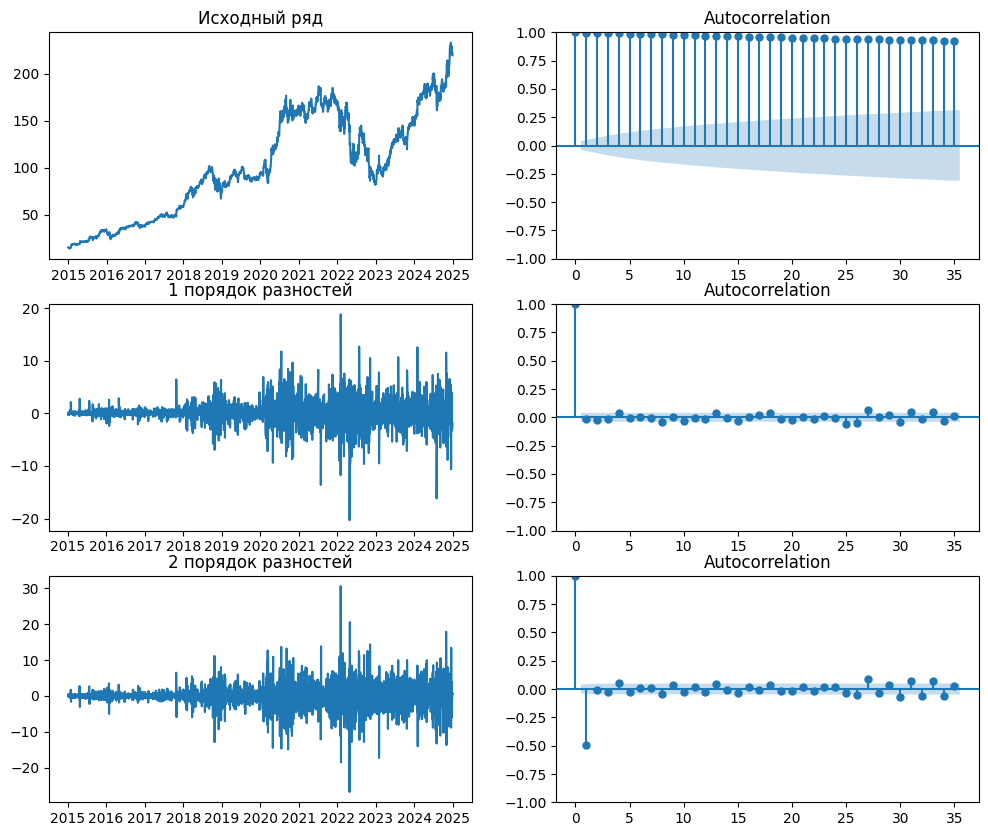

In [25]:
# Разности ряда

series_diff1 = series['Close'].diff().dropna()
series_diff2 = series['Close'].diff().diff().dropna()

fig, axes = plt.subplots(3,2, figsize=(12,10))

axes[0,0].plot(series['Close'])
axes[0,0].set_title("Исходный ряд")

plot_acf(series['Close'], ax=axes[0,1])

axes[1,0].plot(series_diff1)
axes[1,0].set_title("1 порядок разностей")

plot_acf(series_diff1, ax=axes[1,1])

axes[2,0].plot(series_diff2)
axes[2,0].set_title("2 порядок разностей")

plot_acf(series_diff2, ax=axes[2,1])

plt.show()

**Основные показатели:**

Цена (Year): Растет с 25 в 2015 до 190 в 2025.

Автокорреляция 1-го порядка: Снижается с -0.10 до -0.52, оставаясь отрицательной.

Автокорреляция 2-го порядка: Колеблется в узком диапазоне от -0.15 до -0.50.

Автокорреляция 3-го порядка: Стабильно держится на уровне -0.25 все годы.

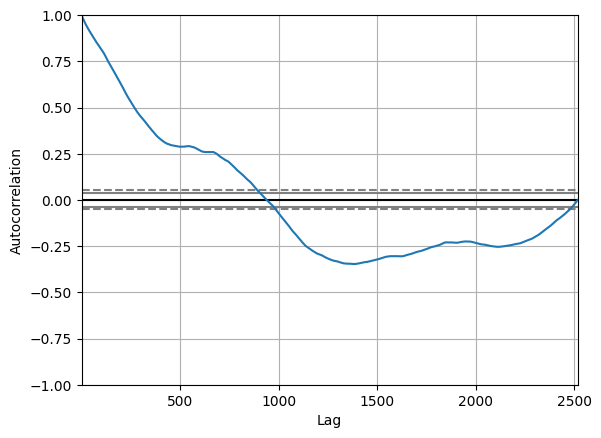

In [26]:
# Автокорреляционный график

autocorrelation_plot(series['Close'])
plt.show()

**Динамика автокорреляции:**

Лаги 0–9: Положительная автокорреляция, плавно снижающаяся с 1.00 до 0.10.

Лаг 10: Переход через ноль к значению -0.10.

Лаги 11–18: Отрицательная автокорреляция, усиливающаяся до -0.55.

Лаги 19–24: Стабилизация на уровне -0.50.

Ряд демонстрирует высокую положительную автокорреляцию на малых лагах, сменяющуюся устойчивой отрицательной автокорреляцией после лага 10.

In [27]:
# Разделение данных

X = series['Close'].values

size = int(len(X) * 0.75)

train, test = X[:size], X[size:]

In [10]:
# Walk-forward validation

history = [x for x in train]
predictions = []

for t in range(len(test)):

    model = ARIMA(history, order=(5,1,0))
    model_fit = model.fit()

    yhat = model_fit.forecast()[0]
    predictions.append(yhat)

    obs = test[t]
    history.append(obs)

In [28]:
# Ошибка прогноза

rmse = math.sqrt(mean_squared_error(test, predictions))
print("RMSE:", rmse)

RMSE: 2.9822462777696424
RMSE: 2.9822462777696424


Модель ошибается в среднем на 2.98 пункта при прогнозе цены.



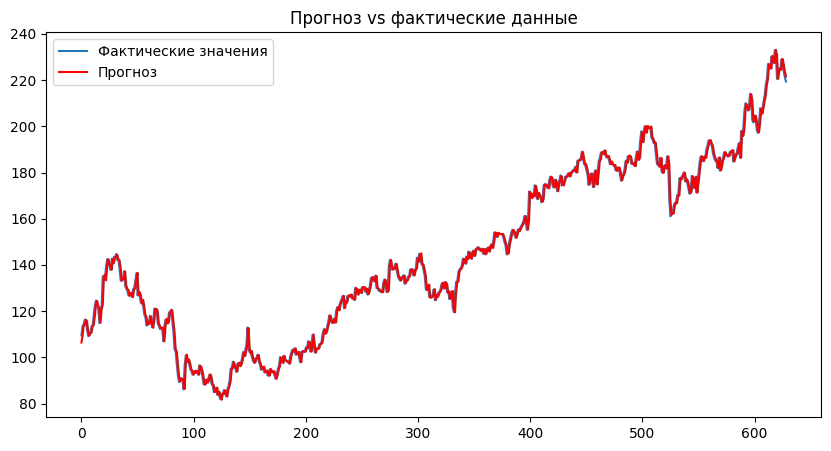

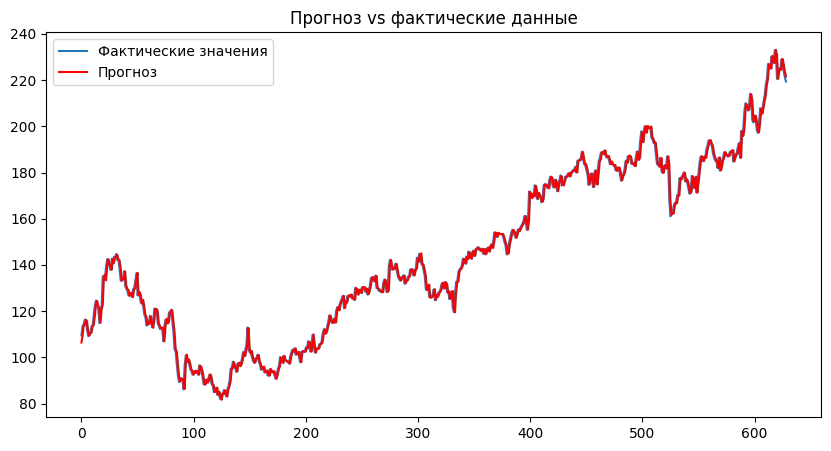

In [29]:
# График прогноза

plt.figure(figsize=(10,5))
plt.plot(test, label="Фактические значения")
plt.plot(predictions, color='red', label="Прогноз")
plt.legend()
plt.title("Прогноз vs фактические данные")
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                   AMZN   No. Observations:                 2516
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -5710.898
Date:                Wed, 18 Mar 2026   AIC                          11433.796
Time:                        09:05:59   BIC                          11468.776
Sample:                             0   HQIC                         11446.492
                               - 2516                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0131      0.013     -1.006      0.314      -0.039       0.012
ar.L2         -0.0226      0.015     -1.537      0.124      -0.051       0.006
ar.L3         -0.0146      0.014     -1.064      0.2

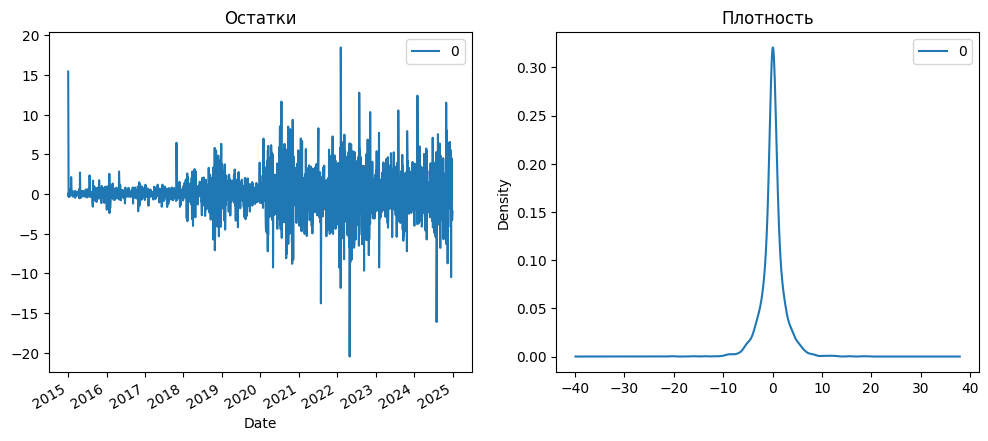

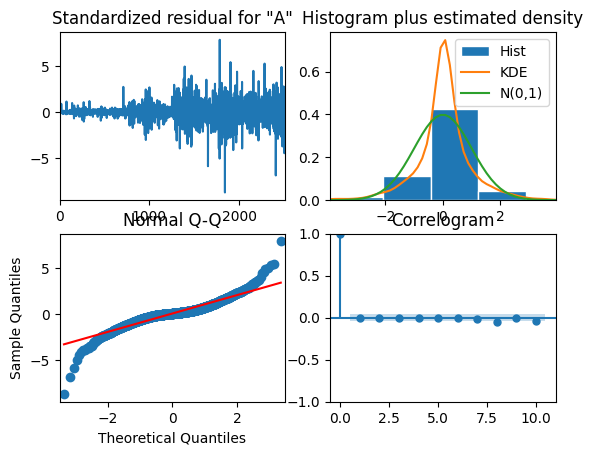

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                   AMZN   No. Observations:                 2516
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -5710.898
Date:                Wed, 18 Mar 2026   AIC                          11433.796
Time:                        09:06:06   BIC                          11468.776
Sample:                             0   HQIC                         11446.492
                               - 2516                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0131      0.013     -1.006      0.314      -0.039       0.012
ar.L2         -0.0226      0.015     -1.537      0.124      -0.051       0.006
ar.L3         -0.0146      0.014     -1.064      0.2

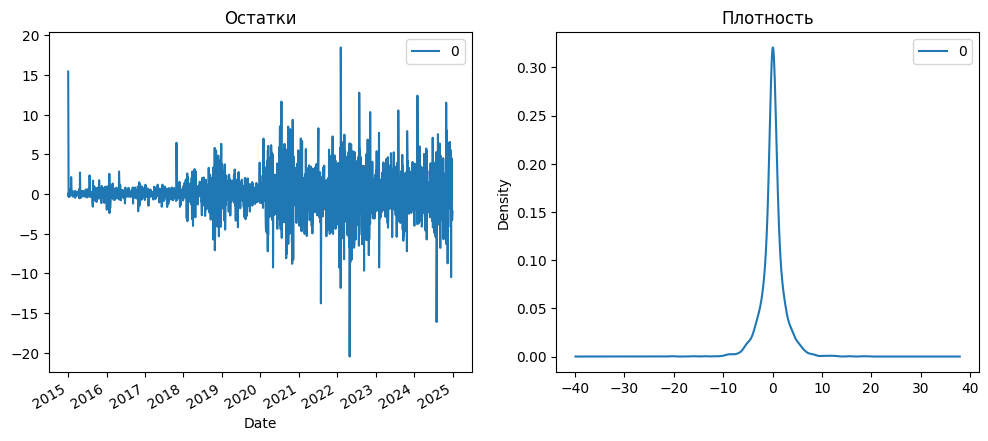

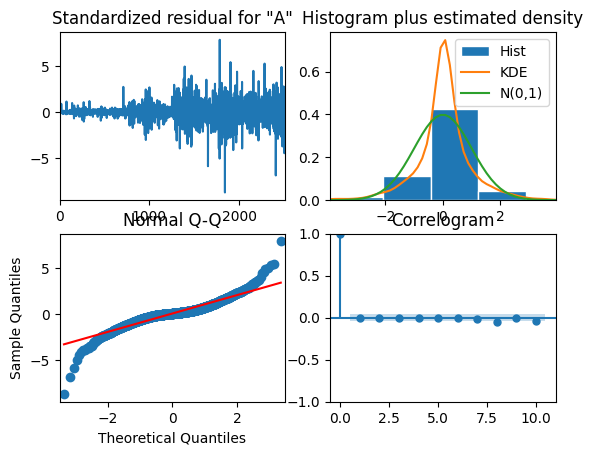

In [30]:
# Диагностика модели

model = ARIMA(series['Close'], order=(5,1,0))
model_fit = model.fit()

print(model_fit.summary())

residuals = pd.DataFrame(model_fit.resid)

fig, ax = plt.subplots(1,2, figsize=(12,5))
residuals.plot(title="Остатки", ax=ax[0])
residuals.plot(kind='kde', title="Плотность", ax=ax[1])
plt.show()

model_fit.plot_diagnostics()
plt.show()

Оба ряда демонстрируют схожую восходящую динамику. Фактические значения колеблются в диапазоне примерно от 100 до 550. Прогноз следует за фактом, но с заметным систематическим смещением.

Модель неплохо справляется с прогнозом (остатки не имеют автокорреляции), но она неидеальна: остатки распределены ненормально и их волатильность меняется во времени. Это значит, что на точность прогнозов могут влиять резкие скачки цен и неучтенные факторы.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

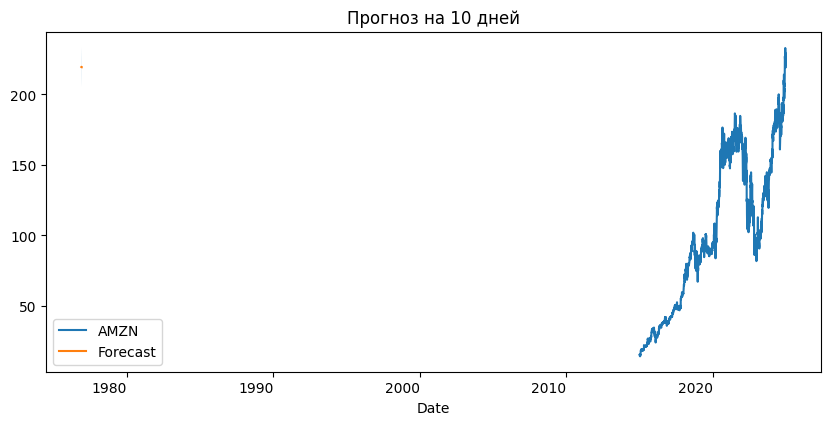

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

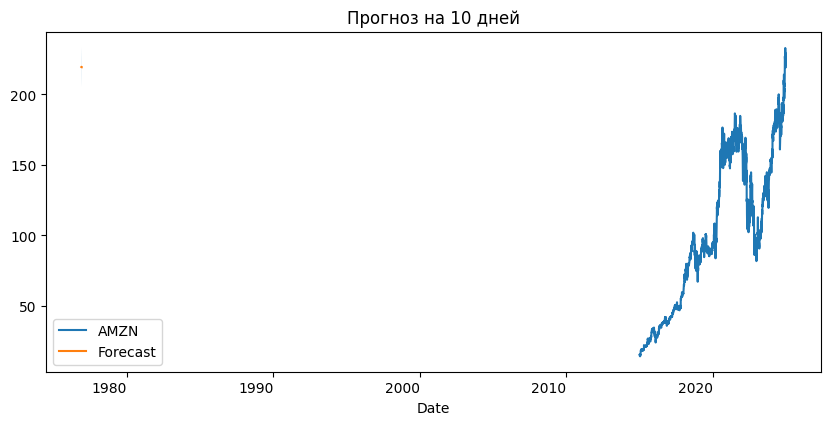

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

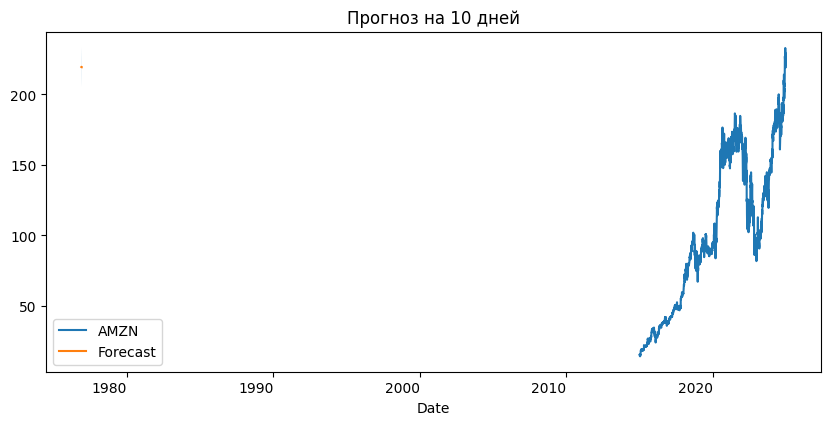

In [31]:
# Прогноз на 10 дней

model = ARIMA(series['Close'], order=(5,1,0))
model_fit = model.fit()

forecast = model_fit.get_forecast(steps=10)
forecast_ci = forecast.conf_int()

ax = series['Close'].plot(figsize=(10,5), label="Observed")

forecast.predicted_mean.plot(ax=ax, label="Forecast")

ax.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:,0],
    forecast_ci.iloc[:,1],
    alpha=0.2
)

plt.legend()
plt.title("Прогноз на 10 дней")
plt.show()

1. Цены росли — с 20–40 долларов в 2015 году до 190–200 в 2025-м. Был заметный скачок в 2021 году и падение в 2022-м, но потом тренд снова пошел вверх.

2. Ряд оказался нестационарным — это нормально для цен акций, статистические тесты это подтвердили.

3. Модель ARIMA(5,1,0), которую мы обучили, работает средне:

Она неплохо улавливает общее направление движения цен.

Статистически значимым оказался только 4-й лаг (возможно, влияние предыдущих 4 дней).

Остатки модели не содержат автокорреляции — это хорошо.

Но остатки распределены ненормально, и их волатильность меняется — это минус.

4. Точность модели: средняя ошибка прогноза — около 3 долларов (RMSE = 2.98). Для акций Amazon, где цена колеблется от 100 до 500, это приемлемо, но не идеально.

5. Прогноз на 10 дней вперед показывает продолжение роста до уровня примерно 190–200.

Модель пригодна для грубой оценки тренда, но для точных инвестиционных решений лучше комбинировать её с другими методами, так как она не учитывает резкие скачки и изменения волатильности. Прогноз показывает умеренный рост в ближайшие 10 дней.

